In [1]:
# Parameters
frequency = "1d"


Cargo los datos

In [2]:
import numpy as np
import pandas as pd
from pylab import plt, mpl
import os
import papermill as pm

# Frecuencia obtenida desde el main
try:
    print(f"Frecuencia recibida desde papermill: {frequency}")
except NameError:
    print(f"No se recibió 'frequency'.")

# Cargar los datos para esta frecuencia de un archivo creado por el main
file_name = f"processed_data_{frequency}_WEMH.csv"
data = pd.read_csv(file_name, index_col='timestamp')
data

Frecuencia recibida desde papermill: 1d


,BTCUSDT_1d,LTCBTC_1d,BNBUSDT_1d,BNBBTC_1d,LTCUSDT_1d,ADABTC_1d,ADAUSDT_1d,SOLUSDT_1d,SOLBTC_1d
timestamp,,,,,,,,,
2020-08-11,11392.08,0.004751,21.2902,0.001869,54.10,0.000012,0.13685,3.2985,0.000289
2020-08-12,11564.33,0.004718,21.4919,0.001860,54.52,0.000012,0.13670,3.7558,0.000324
2020-08-13,11780.00,0.004850,21.7667,0.001849,57.14,0.000012,0.13944,3.7300,0.000316
2020-08-14,11760.54,0.004828,23.1047,0.001964,56.78,0.000012,0.13826,3.4099,0.000290
2020-08-15,11852.40,0.005050,23.0881,0.001949,59.85,0.000012,0.13837,3.1730,0.000268
...,...,...,...,...,...,...,...,...,...
2024-12-28,95300.00,0.001057,722.1300,0.007577,100.74,0.000009,0.88950,195.5000,0.002051
2024-12-29,93738.20,0.001051,694.7100,0.007412,98.51,0.000009,0.85900,189.9400,0.002027
2024-12-30,92792.05,0.001072,705.3600,0.007600,99.40,0.000009,0.86150,191.3800,0.002062


Función para guardar los datos. Hace un archivo por cada frecuencia. Guarda en cada línea el modelo que se ha empleado, el activo, accuracy e in/out-sample.

In [3]:
def save_results(model, ric, acc, sample, frequency=frequency):
    # Verificar si el archivo ya existe
    file_name = f'accuracy_results_{frequency}_WEMH.csv'

    # Si el archivo existe, leer los datos previos, si no, crear un nuevo DataFrame vacío
    if os.path.exists(file_name):
        df_results = pd.read_csv(file_name)
    else:
        df_results = pd.DataFrame(columns=['Model', 'Asset', 'Accuracy', 'IN/OUT Sample'])

    # Agregar la nueva fila con los resultados
    new_row = pd.DataFrame([[model, ric, acc, sample]], columns=['Model', 'Asset', 'Accuracy', 'IN/OUT Sample'])
    df_results = pd.concat([df_results, new_row], ignore_index=True)

    # Guardar los resultados acumulados
    df_results.to_csv(file_name, index=False) 

Representación de los datos

C:\Users\raque\AppData\Local\Temp\ipykernel_22928\1561802692.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


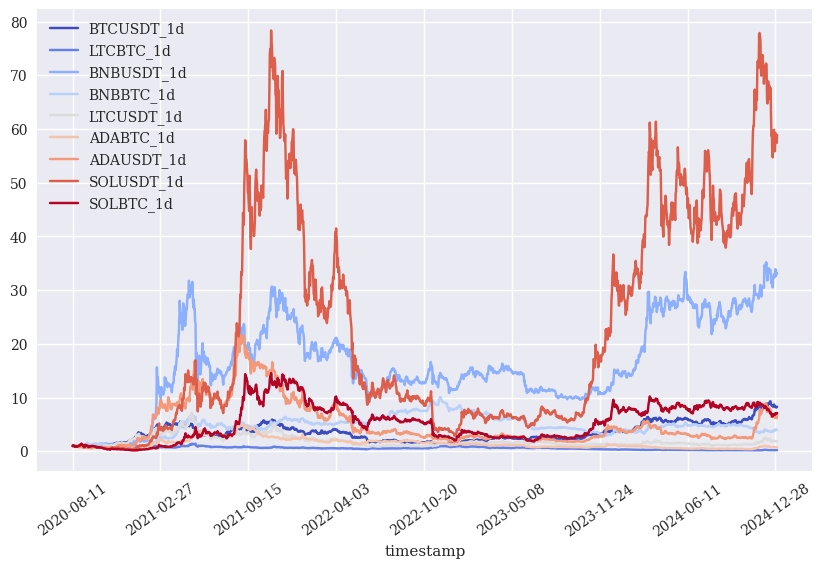

In [4]:
plt.style.use('seaborn')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(suppress=True, precision=4)
(data / data.iloc[0]).plot(figsize=(10, 6), cmap='coolwarm')
plt.xticks(rotation=35)
plt.show()

Retardamos los datos para crear los lags de cada instante de tiempo

In [5]:
lags = 7

def add_lags(data, ric, lags):
    cols = []
    df = pd.DataFrame(data[ric])
    for lag in range(1, lags + 1):
        col = 'lag_{}'.format(lag)
        df[col] = df[ric].shift(lag)
        cols.append(col)
    df.dropna(inplace=True)
    return df, cols

dfs = {}
for sym in data.columns:
    df, cols = add_lags(data, sym, lags) 
    dfs[sym] = df

dfs[sym].head(7)

,SOLBTC_1d,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
timestamp,,,,,,,,
2020-08-18,0.000280,0.000253,0.000284,0.000268,0.000290,0.000316,0.000324,0.000289
2020-08-19,0.000247,0.000280,0.000253,0.000284,0.000268,0.000290,0.000316,0.000324
2020-08-20,0.000271,0.000247,0.000280,0.000253,0.000284,0.000268,0.000290,0.000316
2020-08-21,0.000254,0.000271,0.000247,0.000280,0.000253,0.000284,0.000268,0.000290
2020-08-22,0.000259,0.000254,0.000271,0.000247,0.000280,0.000253,0.000284,0.000268
2020-08-23,0.000279,0.000259,0.000254,0.000271,0.000247,0.000280,0.000253,0.000284
2020-08-24,0.000284,0.000279,0.000259,0.000254,0.000271,0.000247,0.000280,0.000253


In [6]:
# Modificación del tipo a numérico
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df[sym] = pd.to_numeric(df[sym], errors='coerce')
print(dfs[sym])


            SOLBTC_1d     lag_1     lag_2     lag_3     lag_4     lag_5  \
timestamp                                                                 
2020-08-18   0.000280  0.000253  0.000284  0.000268  0.000290  0.000316   
2020-08-19   0.000247  0.000280  0.000253  0.000284  0.000268  0.000290   
2020-08-20   0.000271  0.000247  0.000280  0.000253  0.000284  0.000268   
2020-08-21   0.000254  0.000271  0.000247  0.000280  0.000253  0.000284   
2020-08-22   0.000259  0.000254  0.000271  0.000247  0.000280  0.000253   
...               ...       ...       ...       ...       ...       ...   
2024-12-28   0.002051  0.001954  0.001967  0.001986  0.001998  0.002004   
2024-12-29   0.002027  0.002051  0.001954  0.001967  0.001986  0.001998   
2024-12-30   0.002062  0.002027  0.002051  0.001954  0.001967  0.001986   
2024-12-31   0.002023  0.002062  0.002027  0.002051  0.001954  0.001967   
2025-01-01   0.002054  0.002023  0.002062  0.002027  0.002051  0.001954   

               lag_6    

Se aplica regresión lineal y se muestran los pesos que se le dan a cada lag para hacer la predicción.
Como se puede observar el valor más importante para la predicción es el lag 1, el precio de ayer.

In [7]:
regs = {}
for sym in data.columns:
    df = dfs[sym]
    reg = np.linalg.lstsq(df[cols], df[sym], rcond=-1)[0]
    regs[sym] = reg
rega = np.stack(tuple(regs.values()))
regd = pd.DataFrame(rega, columns=cols, index=data.columns)
regd

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
BTCUSDT_1d,0.963470,0.051873,-0.016541,0.037978,-0.015204,-0.046697,0.025991
LTCBTC_1d,0.950544,0.050043,-0.038058,0.032539,-0.062547,0.112899,-0.047019
BNBUSDT_1d,0.892680,0.177341,-0.024416,-0.041932,-0.088157,0.114012,-0.029256
BNBBTC_1d,0.959521,0.105541,-0.045732,-0.037812,-0.039543,0.090655,-0.032817
LTCUSDT_1d,0.928435,0.108126,-0.057753,0.121652,-0.128374,0.066903,-0.040760
ADABTC_1d,1.010462,0.042294,-0.112420,0.105332,-0.014916,-0.035206,0.003505
ADAUSDT_1d,0.920138,0.083018,-0.075838,0.112521,-0.072686,0.047647,-0.015938
SOLUSDT_1d,0.996802,0.024995,-0.000940,0.037422,-0.140665,0.108908,-0.026696
SOLBTC_1d,1.079914,-0.046347,-0.009043,-0.014043,-0.048995,0.012690,0.025234


Observamos que los lags están muy relacionados por lo que todos nos aportan más o menos la misma información.

In [8]:
dfs[sym].corr()

,SOLBTC_1d,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
SOLBTC_1d,1.000000,0.997019,0.993536,0.989810,0.985912,0.981944,0.978202,0.974646
lag_1,0.997019,1.000000,0.997022,0.993542,0.989818,0.985923,0.981961,0.978223
lag_2,0.993536,0.997022,1.000000,0.997025,0.993548,0.989827,0.985935,0.981978
lag_3,0.989810,0.993542,0.997025,1.000000,0.997027,0.993552,0.989838,0.985950
lag_4,0.985912,0.989818,0.993548,0.997027,1.000000,0.997030,0.993559,0.989848
lag_5,0.981944,0.985923,0.989827,0.993552,0.997030,1.000000,0.997035,0.993566
lag_6,0.978202,0.981961,0.985935,0.989838,0.993559,0.997035,1.000000,0.997037
lag_7,0.974646,0.978223,0.981978,0.985950,0.989848,0.993566,0.997037,1.000000


Hacemos un test de Augmented Dickey-Fuller para comprobar la estacionariedad de los datos. 
Como el primer valor es mayor que todos los valores de disintos niveles de confianza no podemos asegurar que la serie sea estacionaria.

In [9]:
from statsmodels.tsa.stattools import adfuller
adfuller(data[sym].dropna())

(-1.9208539472543271,
 0.32231524016224145,
 19,
 1585,
 {'1%': -3.4344824429999132,
  '5%': -2.863365228537185,
  '10%': -2.567741717501418},
 -25431.242149966525)

Ahora calculamos los retornos logaritmicos para poder hacer una aprendizaje con una característica. Intentando que esta sea estacionaria al contrario que los precios tal cual. Normalizamos los retornos y mostramos los retornos retardados.

C:\Users\raque\AppData\Local\Temp\ipykernel_22928\1388203415.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


<Axes: xlabel='timestamp'>

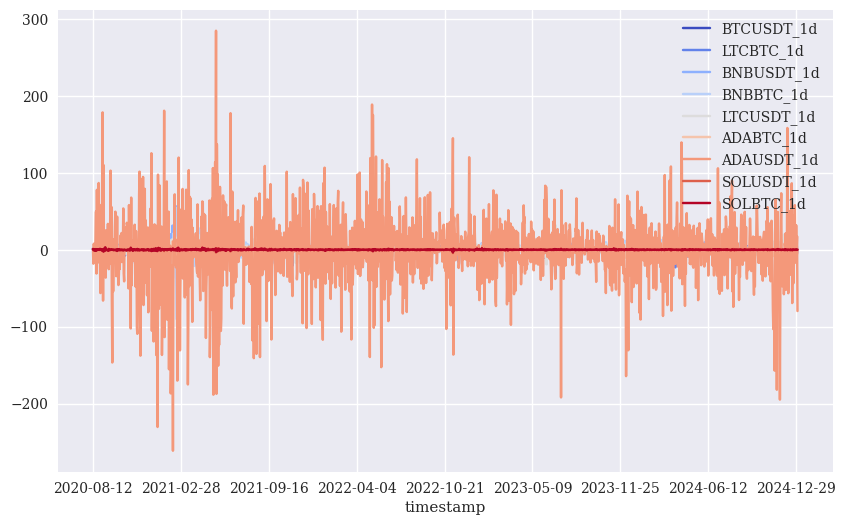

In [10]:
rets = np.log(data / data.shift(1))
rets.dropna(inplace=True)
plt.style.use('seaborn')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(suppress=True, precision=4)
(rets / rets.iloc[0]).plot(figsize=(10, 6), cmap='coolwarm')

In [11]:
dfs = {}
for sym in data:
    df, cols = add_lags(rets, sym, lags)
    mu, std = df[cols].mean(), df[cols].std() 
    df[cols] = (df[cols] - mu) / std
    dfs[sym] = df

dfs[sym].head() 


,SOLBTC_1d,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
timestamp,,,,,,,,
2020-08-19,-0.127405,1.830724,-2.102717,1.028510,-1.502246,-1.575429,-0.490038,2.114908
2020-08-20,0.092756,-2.353250,1.829349,-2.102538,1.028590,-1.499900,-1.575106,-0.490802
2020-08-21,-0.063310,1.672138,-2.349002,1.828330,-2.100299,1.029559,-1.499582,-1.574360
2020-08-22,0.018258,-1.181344,1.670976,-2.348747,1.827859,-2.097627,1.029703,-1.498941
2020-08-23,0.076805,0.310032,-1.178671,1.670006,-2.346338,1.828392,-2.097269,1.026825


Los retornos sí son estacionarios.

In [12]:
adfuller(dfs[sym]['lag_1']) 


(-17.72502357986014,
 3.454830994842134e-30,
 4,
 1592,
 {'1%': -3.4344642432857992,
  '5%': -2.8633571955690647,
  '10%': -2.5677374399794197},
 4354.982488360665)

Y no están correlados.

In [13]:
dfs[sym].corr()

,SOLBTC_1d,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
SOLBTC_1d,1.000000,-0.000951,-0.041345,0.070989,0.022165,-0.042321,0.022618,0.034857
lag_1,-0.000951,1.000000,-0.003304,-0.040156,0.069181,0.020184,-0.042814,0.025021
lag_2,-0.041345,-0.003304,1.000000,-0.004586,-0.038150,0.071328,0.020768,-0.045529
lag_3,0.070989,-0.040156,-0.004586,1.000000,-0.005506,-0.039292,0.071012,0.022131
lag_4,0.022165,0.069181,-0.038150,-0.005506,1.000000,-0.003884,-0.038823,0.068843
lag_5,-0.042321,0.020184,0.071328,-0.039292,-0.003884,1.000000,-0.003318,-0.040733
lag_6,0.022618,-0.042814,0.020768,0.071012,-0.038823,-0.003318,1.000000,-0.003981
lag_7,0.034857,0.025021,-0.045529,0.022131,0.068843,-0.040733,-0.003981,1.000000


Predicciones sin train split, probablemente sobreajustadas.

In [14]:
from sklearn.metrics import accuracy_score

for sym in data:
    df = dfs[sym]
    reg = np.linalg.lstsq(df[cols], df[sym], rcond=-1)[0]
    pred = np.dot(df[cols], reg)
    acc = accuracy_score(np.sign(df[sym]), np.sign(pred))
    print(f'OLS | {sym:10s} | acc={acc:.4f}')
    save_results('OLS', sym, acc, "IN-SAMPLE")

OLS | BTCUSDT_1d | acc=0.5059
OLS | LTCBTC_1d  | acc=0.5385
OLS | BNBUSDT_1d | acc=0.5210
OLS | BNBBTC_1d  | acc=0.5022
OLS | LTCUSDT_1d | acc=0.5097
OLS | ADABTC_1d  | acc=0.5085
OLS | ADAUSDT_1d | acc=0.5085
OLS | SOLUSDT_1d | acc=0.5160
OLS | SOLBTC_1d  | acc=0.4897


C:\Users\raque\AppData\Local\Temp\ipykernel_22928\1535030461.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_row], ignore_index=True)


In [15]:
from sklearn.neural_network import MLPRegressor
for sym in data.columns:
    df = dfs[sym]
    model = MLPRegressor(hidden_layer_sizes=[512],
                        random_state=100,
                        max_iter=1000,
                        early_stopping=True,
                        validation_fraction=0.15,
                        shuffle=False)
    model.fit(df[cols], df[sym])
    pred = model.predict(df[cols])
    acc = accuracy_score(np.sign(df[sym]), np.sign(pred))
    print(f'MLP | {sym:10s} | acc={acc:.4f}')
    save_results('MLP', sym, acc, "IN-SAMPLE")

MLP | BTCUSDT_1d | acc=0.6744


MLP | LTCBTC_1d  | acc=0.5598


MLP | BNBUSDT_1d | acc=0.6349


MLP | BNBBTC_1d  | acc=0.5604


MLP | LTCUSDT_1d | acc=0.5579


MLP | ADABTC_1d  | acc=0.5535


MLP | ADAUSDT_1d | acc=0.6224


MLP | SOLUSDT_1d | acc=0.5510


MLP | SOLBTC_1d  | acc=0.5673


Ahora entrenamos con unos datos y testeamos con otros (80% entrenamiento, 20% test).

In [16]:
split = int(len(dfs[sym]) * 0.8)
for sym in data.columns:
    df = dfs[sym]
    train = df.iloc[:split]
    reg = np.linalg.lstsq(train[cols], train[sym], rcond=-1)[0]
    test = df.iloc[split:]
    pred = np.dot(test[cols], reg)
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'OLS | {sym:10s} | acc={acc:.4f}')
    save_results('OLS', sym, acc, "OUT-SAMPLE")

OLS | BTCUSDT_1d | acc=0.4875
OLS | LTCBTC_1d  | acc=0.5437
OLS | BNBUSDT_1d | acc=0.4969
OLS | BNBBTC_1d  | acc=0.4938
OLS | LTCUSDT_1d | acc=0.4656
OLS | ADABTC_1d  | acc=0.4656
OLS | ADAUSDT_1d | acc=0.4813
OLS | SOLUSDT_1d | acc=0.4625
OLS | SOLBTC_1d  | acc=0.4594


In [17]:
for sym in data.columns:
    df = dfs[sym]
    train = df.iloc[:split]
    model = MLPRegressor(hidden_layer_sizes=[512],
                        random_state=100,
                        max_iter=1000,
                        early_stopping=True,
                        validation_fraction=0.15,
                        shuffle=False)
    model.fit(train[cols], train[sym])
    test = df.iloc[split:]
    pred = model.predict(test[cols])
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'MLP | {sym:10s} | acc={acc:.4f}')
    save_results('MLP', sym, acc, "OUT-SAMPLE")

MLP | BTCUSDT_1d | acc=0.5062


MLP | LTCBTC_1d  | acc=0.4656


MLP | BNBUSDT_1d | acc=0.4750


MLP | BNBBTC_1d  | acc=0.5156


MLP | LTCUSDT_1d | acc=0.5406


MLP | ADABTC_1d  | acc=0.5375


MLP | ADAUSDT_1d | acc=0.5375


MLP | SOLUSDT_1d | acc=0.5156


MLP | SOLBTC_1d  | acc=0.4906


In [18]:
import tensorflow as tf
from keras.layers import Dense
from keras.models import Sequential

np.random.seed(100)
tf.random.set_seed(100)

def create_model(problem='regression'):
    model = Sequential()
    model.add(Dense(512, input_dim=len(cols),
                    activation='relu'))
    if problem == 'regression':
        model.add(Dense(1, activation='linear'))
        model.compile(loss='mse', optimizer='adam')
    else:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(loss='binary_crossentropy', optimizer='adam')
    return model


for sym in data.columns[:]:
    df = dfs[sym]
    train = df.iloc[:split]
    test = df.iloc[split:]
    model = create_model()
    model.fit(train[cols], train[sym], epochs=25, verbose=False)
    pred = model.predict(test[cols])
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'DNN | {sym:10s} | acc={acc:.4f}')
    save_results('DNN', sym, acc, "OUT-SAMPLE")

C:\Users\raque\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


DNN | BTCUSDT_1d | acc=0.4562


C:\Users\raque\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

DNN | SOLUSDT_1d | acc=0.4750


C:\Users\raque\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


DNN | SOLBTC_1d  | acc=0.5062


Como podemos ver los resultados no son muy esperanzadores por lo que podemos asumir que los mercados son eficientes al menos en la forma debil. Es decir que no es posible sacar beneficios utilizando unicamente los valores pasados de las acciones. 